In [1]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, random_split, Subset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)
# [NEW] 01~07.ipynb에 없는 설정: cudnn 연산의 비결정성을 줄여 재현성을 높인다
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import platform
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False
print('적용된 폰트:', plt.rcParams['font.family'])


cuda
적용된 폰트: ['Malgun Gothic']


# 쓰레기 이미지 12종 분류 — 데이터 정제 반영 재구축 (3.ipynb)

`1.ipynb`(1차 파이프라인)와 `2.ipynb`(중복·라벨오류 탐지)에서 찾아낸 문제를, **팀 논의로 확정한 정제 원칙**에 따라 반영한 뒤 모델링 파이프라인을 다시 학습·평가한다.

**정제 원칙 (팀 합의, `data_cleaning_summary.md` 참고)**

| 구분 | 처리 |
|---|---|
| 완전 동일 중복 | 제거 |
| 근접 중복 | 삭제하지 않고 같은 data split에만 배치 |
| 라벨 오류 | 맞는 라벨로 정정 |
| 애매한 경계 / 비사진 파일 | 삭제 |

원본 `garbage_classification/` 폴더의 파일은 옮기거나 지우지 않는다. 대신 **매니페스트(파일 경로 → 최종 라벨) 테이블**을 코드로 만들어 반영한다.

**v2 변경점**: 1차 버전에서는 전처리/샘플링 방식과 unfreeze 학습률을 `1.ipynb`에서 검증으로 확정한 값을 그대로 이월해서 썼다. 이번엔 그 이월을 걷어내고, **정제된 데이터 위에서 전처리·불균형 대응 2x2 그리드와 학습률 스윕을 처음부터 다시 돌려서** 같은 결론이 나오는지 확인한다(데이터가 바뀌었으니 최적 설정도 바뀔 수 있음).

EDA(클래스별 샘플 이미지, 이미지 크기/모드/손상 여부 점검)는 정제로 달라지지 않는 부분이라 `1.ipynb`의 결과를 참고하고, 이 노트북은 정제 전/후 클래스 분포 비교부터 시작한다.

## 1. 원본 데이터 현황 (요약)

In [2]:
data_dir = './garbage_classification'
class_names = sorted(os.listdir(data_dir))
raw_counts = {c: len(glob(os.path.join(data_dir, c, '*.jpg'))) for c in class_names}

print(f'클래스 수: {len(class_names)}개, 전체 이미지 수(정제 전): {sum(raw_counts.values())}장')
for c, n in raw_counts.items():
    print(f'{c:12s}: {n:5d}장')


클래스 수: 12개, 전체 이미지 수(정제 전): 15515장
battery     :   945장
biological  :   985장
brown-glass :   607장
cardboard   :   891장
clothes     :  5325장
green-glass :   629장
metal       :   769장
paper       :  1050장
plastic     :   865장
shoes       :  1977장
trash       :   697장
white-glass :   775장


## 2. 데이터 정제 — 매니페스트 구성 (팀 합의안 반영)

`2.ipynb`(자동 탐지 + 사람 육안 검토) → `label_review_report.md`(train OOF까지 확장 검토) → `data_cleaning_summary.md`(최종 정리)를 거쳐 확정된 목록을 반영한다.

In [3]:
# --- 1) 완전 동일 중복(MD5) - 같은 클래스: 파일명 기준 한쪽만 제거 (16장) ---
exact_dup_delete_same_class = [
    'clothes5234.jpg',
    'green-glass530.jpg', 'green-glass555.jpg', 'green-glass443.jpg', 'green-glass554.jpg',
    'green-glass461.jpg', 'green-glass459.jpg', 'green-glass564.jpg', 'green-glass517.jpg',
    'green-glass563.jpg', 'green-glass482.jpg', 'green-glass561.jpg', 'green-glass565.jpg',
    'green-glass544.jpg', 'green-glass492.jpg', 'green-glass592.jpg',
]

# --- 2) 완전 동일 중복(MD5) - 클래스가 다름: 라벨 신뢰 불가로 양쪽 다 제거 (3쌍 6장) ---
cross_class_exact_dup_pairs = [
    ('metal459.jpg', 'white-glass412.jpg'),
    ('plastic159.jpg', 'white-glass129.jpg'),
    ('plastic556.jpg', 'white-glass761.jpg'),
]
cross_class_exact_dup_delete = [f for pair in cross_class_exact_dup_pairs for f in pair]

# --- 3) 근접 중복(dHash+픽셀 검증, 사람이 오탐 제외까지 마침): 삭제하지 않고 같은 split 단위로 묶음 (42그룹) ---
near_dup_groups = [
    ('battery268.jpg', 'battery343.jpg'),
    ('battery63.jpg', 'battery833.jpg'),
    ('battery759.jpg', 'battery945.jpg'),
    ('biological401.jpg', 'biological709.jpg'),
    ('biological402.jpg', 'biological781.jpg'),
    ('biological410.jpg', 'biological865.jpg'),
    ('brown-glass19.jpg', 'brown-glass439.jpg'),
    ('clothes2051.jpg', 'clothes5234.jpg'),
    ('clothes5095.jpg', 'clothes536.jpg'),
    ('green-glass190.jpg', 'green-glass46.jpg'),
    ('green-glass2.jpg', 'green-glass292.jpg', 'green-glass443.jpg'),
    ('green-glass228.jpg', 'green-glass433.jpg'),
    ('green-glass231.jpg', 'green-glass530.jpg'),
    ('green-glass285.jpg', 'green-glass555.jpg'),
    ('green-glass336.jpg', 'green-glass554.jpg'),
    ('green-glass349.jpg', 'green-glass461.jpg'),
    ('green-glass388.jpg', 'green-glass459.jpg'),
    ('green-glass403.jpg', 'green-glass564.jpg'),
    ('green-glass413.jpg', 'green-glass517.jpg', 'green-glass563.jpg'),
    ('green-glass422.jpg', 'green-glass482.jpg'),
    ('green-glass424.jpg', 'green-glass561.jpg'),
    ('green-glass449.jpg', 'green-glass565.jpg'),
    ('green-glass451.jpg', 'green-glass488.jpg'),
    ('green-glass471.jpg', 'green-glass544.jpg'),
    ('green-glass476.jpg', 'green-glass492.jpg'),
    ('green-glass583.jpg', 'green-glass592.jpg'),
    ('metal459.jpg', 'white-glass412.jpg'),
    ('metal590.jpg', 'metal745.jpg'),
    ('plastic159.jpg', 'white-glass129.jpg'),
    ('plastic467.jpg', 'plastic506.jpg'),
    ('plastic556.jpg', 'white-glass761.jpg'),
    ('shoes1049.jpg', 'shoes1390.jpg'),
    ('shoes1065.jpg', 'shoes1482.jpg', 'shoes651.jpg'),
    ('shoes1095.jpg', 'shoes777.jpg'),
    ('shoes1128.jpg', 'shoes615.jpg'),
    ('shoes1227.jpg', 'shoes1368.jpg'),
    ('shoes29.jpg', 'shoes621.jpg'),
    ('trash238.jpg', 'trash301.jpg'),
    ('trash254.jpg', 'trash559.jpg'),
    ('trash683.jpg', 'trash688.jpg'),
    ('white-glass300.jpg', 'white-glass472.jpg'),
    ('white-glass674.jpg', 'white-glass688.jpg'),
]

# --- 4) 라벨 오류: 맞는 라벨로 정정 (46장) ---
clothes_to_shoes = [
    'clothes3062.jpg', 'clothes3330.jpg', 'clothes5002.jpg', 'clothes2197.jpg', 'clothes4465.jpg',
    'clothes1229.jpg', 'clothes2272.jpg', 'clothes791.jpg', 'clothes4836.jpg', 'clothes5277.jpg',
    'clothes5181.jpg', 'clothes3623.jpg', 'clothes3807.jpg', 'clothes451.jpg', 'clothes2162.jpg',
    'clothes4329.jpg', 'clothes255.jpg', 'clothes559.jpg', 'clothes2185.jpg', 'clothes4319.jpg',
    'clothes4611.jpg', 'clothes5201.jpg', 'clothes2556.jpg', 'clothes1015.jpg', 'clothes82.jpg',
    'clothes3374.jpg', 'clothes4466.jpg', 'clothes4635.jpg', 'clothes2334.jpg', 'clothes2654.jpg',
    'clothes4150.jpg', 'clothes1312.jpg', 'clothes4293.jpg', 'clothes2733.jpg', 'clothes53.jpg',
    'clothes3206.jpg', 'clothes5045.jpg', 'clothes1444.jpg', 'clothes4495.jpg', 'clothes4469.jpg',
    'clothes3895.jpg', 'clothes1582.jpg', 'clothes3545.jpg',
]
label_corrections = {f: 'shoes' for f in clothes_to_shoes}
label_corrections['shoes1826.jpg'] = 'clothes'
label_corrections['white-glass704.jpg'] = 'green-glass'
label_corrections['paper9.jpg'] = 'plastic'

# --- 5) 애매한 경계 / 비사진 파일: 삭제 (3장 + 6장) ---
exclude_ambiguous = ['white-glass58.jpg', 'shoes379.jpg', 'clothes526.jpg']
exclude_nonphoto = ['trash223.jpg', 'plastic605.jpg', 'white-glass112.jpg',
                    'metal502.jpg', 'green-glass372.jpg', 'shoes1878.jpg']

assert len(exact_dup_delete_same_class) == 16
assert len(cross_class_exact_dup_delete) == 6
assert len(near_dup_groups) == 42
assert len(label_corrections) == 46
assert len(exclude_ambiguous) == 3
assert len(exclude_nonphoto) == 6
print('정제 규칙 목록 건수 확인 완료')


정제 규칙 목록 건수 확인 완료


In [4]:
# 전체 파일을 스캔해 (경로, 원본 클래스, 파일명) 목록을 만든 뒤, 위 규칙을 반영한 매니페스트를 구성한다.
# 파일을 실제로 옮기거나 지우지 않고, 이 매니페스트(리스트)만으로 최종 라벨/제외 여부를 관리한다.
all_files = []
for c in class_names:
    for p in sorted(glob(os.path.join(data_dir, c, '*.jpg'))):
        all_files.append({'path': p, 'orig_class': c, 'fname': os.path.basename(p)})

exclude_set = (set(exact_dup_delete_same_class) | set(cross_class_exact_dup_delete)
              | set(exclude_ambiguous) | set(exclude_nonphoto))

manifest = []
for item in all_files:
    if item['fname'] in exclude_set:
        continue
    final_class = label_corrections.get(item['fname'], item['orig_class'])
    manifest.append({'path': item['path'], 'orig_class': item['orig_class'],
                     'class': final_class, 'fname': item['fname']})

n_relabeled = sum(1 for m in manifest if m['class'] != m['orig_class'])

print(f'스캔한 전체 파일 수: {len(all_files)}장')
print(f'제외(완전동일중복 {len(exact_dup_delete_same_class) + len(cross_class_exact_dup_delete)}장 '
      f'+ 애매/비사진 {len(exclude_ambiguous) + len(exclude_nonphoto)}장) = {len(exclude_set)}장')
print(f'정제 후 남은 파일 수: {len(manifest)}장')
print(f'라벨 정정 반영: {n_relabeled}장')
assert len(manifest) == len(all_files) - len(exclude_set)
assert n_relabeled == len(label_corrections)


스캔한 전체 파일 수: 15515장
제외(완전동일중복 22장 + 애매/비사진 9장) = 31장
정제 후 남은 파일 수: 15484장
라벨 정정 반영: 46장


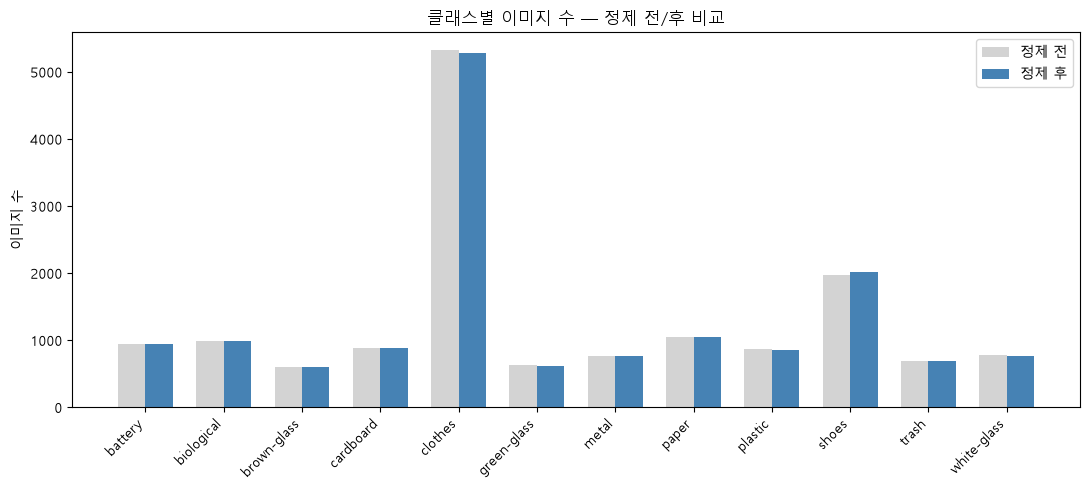

클래스             정제 전    정제 후      증감
battery          945     945      +0
biological       985     985      +0
brown-glass      607     607      +0
cardboard        891     891      +0
clothes         5325    5281     -44
green-glass      629     614     -15
metal            769     767      -2
paper           1050    1049      -1
plastic          865     863      -2
shoes           1977    2017     +40
trash            697     696      -1
white-glass      775     769      -6

정제 후 최다: clothes(5281장) / 최소: brown-glass(607장) / 비율: 8.70배


In [5]:
from collections import Counter

clean_counts = Counter(m['class'] for m in manifest)
clean_counts = {c: clean_counts.get(c, 0) for c in class_names}

x = np.arange(len(class_names))
width = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - width/2, [raw_counts[c] for c in class_names], width, label='정제 전', color='lightgray')
plt.bar(x + width/2, [clean_counts[c] for c in class_names], width, label='정제 후', color='steelblue')
plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('이미지 수')
plt.title('클래스별 이미지 수 — 정제 전/후 비교')
plt.legend()
plt.tight_layout()
plt.show()

print(f'{"클래스":12s}{"정제 전":>8s}{"정제 후":>8s}{"증감":>8s}')
for c in class_names:
    diff = clean_counts[c] - raw_counts[c]
    print(f'{c:12s}{raw_counts[c]:8d}{clean_counts[c]:8d}{diff:+8d}')

max_c = max(clean_counts, key=clean_counts.get)
min_c = min(clean_counts, key=clean_counts.get)
print(f'\n정제 후 최다: {max_c}({clean_counts[max_c]}장) / 최소: {min_c}({clean_counts[min_c]}장) '
      f'/ 비율: {clean_counts[max_c] / clean_counts[min_c]:.2f}배')


## 3. 데이터 분할

`1.ipynb`와 같은 방식(클래스별 70/15/15 stratified 분할, 근접 중복은 Union-Find로 묶어 같은 split에만 배치)을 매니페스트 기준으로 적용한다.

In [6]:
# 매니페스트에 최종 라벨의 정수 인덱스 부여
class_to_idx = {c: i for i, c in enumerate(class_names)}
targets = np.array([class_to_idx[m['class']] for m in manifest])
paths = [m['path'] for m in manifest]
fnames = [m['fname'] for m in manifest]
fname_to_idx = {f: i for i, f in enumerate(fnames)}  # 파일명은 데이터셋 전체에서 유일함

# 근접 중복 그룹을 같은 분할 단위(cluster)로 묶는다 (1.ipynb와 동일한 Union-Find 방식)
# [NEW] 01~07.ipynb에 없는 기법: Union-Find로 근접 중복 파일들을 같은 분할 단위로 묶음
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb

uf = UnionFind(len(manifest))
for group in near_dup_groups:
    members = [fname_to_idx[f] for f in group if f in fname_to_idx]
    for m_idx in members[1:]:
        uf.union(members[0], m_idx)

from collections import defaultdict
clusters_by_root = defaultdict(list)
for i in range(len(manifest)):
    clusters_by_root[uf.find(i)].append(i)
clusters = list(clusters_by_root.values())
n_multi = sum(1 for c in clusters if len(c) > 1)
print(f'분할 단위(덩어리) 수: {len(clusters)}개 (이 중 {n_multi}개는 근접 중복을 하나로 묶은 덩어리)')

# 클래스별 70/15/15 분할을 덩어리 단위로 수행
train_idx, val_idx, test_idx = [], [], []
rng = np.random.RandomState(42)
for c_idx in range(len(class_names)):
    c_clusters = [cluster for cluster in clusters if targets[cluster[0]] == c_idx]
    rng.shuffle(c_clusters)

    n = sum(len(cluster) for cluster in c_clusters)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)

    cum = 0
    for cluster in c_clusters:
        if cum < n_train:
            train_idx += cluster
        elif cum < n_train + n_val:
            val_idx += cluster
        else:
            test_idx += cluster
        cum += len(cluster)

print(f'train {len(train_idx)} / val {len(val_idx)} / test {len(test_idx)} '
      f'(총 {len(train_idx) + len(val_idx) + len(test_idx)})')


분할 단위(덩어리) 수: 15458개 (이 중 25개는 근접 중복을 하나로 묶은 덩어리)
train 10832 / val 2318 / test 2334 (총 15484)


In [7]:
# 클래스 불균형 대응 (A): train 기준 1/count 클래스 가중치
train_targets = targets[train_idx]
counts = np.array([np.sum(train_targets == c) for c in range(len(class_names))])
class_weight_np = (1.0 / counts) * (counts.sum() / len(counts))
class_weights = torch.tensor(class_weight_np, dtype=torch.float32, device=device)

for c, w in zip(class_names, class_weight_np):
    print(f'{c:12s}: weight={w:.3f}')


battery     : weight=1.366
biological  : weight=1.310
brown-glass : weight=2.129
cardboard   : weight=1.449
clothes     : weight=0.244
green-glass : weight=2.104
metal       : weight=1.684
paper       : weight=1.230
plastic     : weight=1.494
shoes       : weight=0.640
trash       : weight=1.854
white-glass : weight=1.678


## 4. 전처리 · 불균형 대응 방식 비교 (val 기준, 정제 데이터로 재탐색)

`1.ipynb`에서는 이 비교를 정제 전 데이터로 한 번 하고 그 결론(비율유지 크롭 + `WeightedRandomSampler`)을 이후 계속 이월해서 썼다. 이번엔 **이월하지 않고, 정제된 데이터에서 처음부터 다시** 리사이즈 방식(정사각형 강제 vs 비율유지+크롭) x 불균형 대응(클래스 가중치 vs `WeightedRandomSampler`) 2x2 = 4가지 조합을 비교한다.

In [8]:
IMAGE_SIZE = 128
BATCH_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# (A) 정사각형으로 강제 리사이즈
train_tf_squash = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

eval_tf_squash = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# (B) 원본 비율을 유지한 채 짧은 변 기준으로 리사이즈 후 크롭
CROP_RESIZE = int(IMAGE_SIZE * 1.15)

train_tf_crop = transforms.Compose([
    transforms.Resize(CROP_RESIZE),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

eval_tf_crop = transforms.Compose([
    transforms.Resize(CROP_RESIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])


In [9]:
# 매니페스트(파일 경로 리스트 + 라벨 리스트) 기반 커스텀 Dataset
# (ImageFolder는 폴더명을 그대로 라벨로 쓰기 때문에, 라벨을 정정한 매니페스트에는 쓸 수 없음)
class ManifestDataset(Dataset):
    def __init__(self, paths, targets, transform=None):
        self.paths = paths
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.targets[idx])


def make_loaders(tr_tf, ev_tf, use_sampler):
    train_paths = [paths[i] for i in train_idx]
    val_paths = [paths[i] for i in val_idx]
    test_paths = [paths[i] for i in test_idx]

    train_set = ManifestDataset(train_paths, targets[train_idx], transform=tr_tf)
    val_set = ManifestDataset(val_paths, targets[val_idx], transform=ev_tf)
    test_set = ManifestDataset(test_paths, targets[test_idx], transform=ev_tf)

    if use_sampler:
        weights = class_weight_np[train_targets]
        sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler)
    else:
        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
    return train_set, val_set, test_set, train_loader, val_loader, test_loader


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    losses, preds_all, trues_all = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)

        if criterion is not None:
            losses.append(criterion(logits, yb).item() * len(yb))

        preds_all.append(logits.argmax(dim=1).cpu().numpy())
        trues_all.append(yb.cpu().numpy())

    preds = np.concatenate(preds_all)
    trues = np.concatenate(trues_all)
    report = classification_report(trues, preds, output_dict=True, zero_division=0)

    return {
        'loss': (sum(losses) / len(trues)) if criterion is not None else None,
        'accuracy': accuracy_score(trues, preds),
        'macro_f1': report['macro avg']['f1-score'],
        'macro_recall': report['macro avg']['recall'],
        'preds': preds,
        'trues': trues}


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3,
                class_weights=None, ckpt_path='best_model.pt', label='model',
                patience=5, use_scheduler=False, scheduler_patience=1):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=scheduler_patience, min_lr=1e-7) if use_scheduler else None

    history = {k: [] for k in ['loss', 'val_loss', 'accuracy', 'val_accuracy',
                               'val_macro_f1', 'val_macro_recall']}
    best_f1 = -1.0
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0
        t0 = time.time()

        for xb, yb in tqdm(train_loader, desc=f'[{label}] Epoch {epoch}/{epochs}', leave=False):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * len(yb)
            run_correct += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)

        tr_loss, tr_acc = run_loss / n, run_correct / n
        m = evaluate(model, val_loader, criterion)
        if scheduler is not None:
            scheduler.step(m['loss'])

        history['loss'].append(tr_loss)
        history['val_loss'].append(m['loss'])
        history['accuracy'].append(tr_acc)
        history['val_accuracy'].append(m['accuracy'])
        history['val_macro_f1'].append(m['macro_f1'])
        history['val_macro_recall'].append(m['macro_recall'])

        if m['macro_f1'] > best_f1:
            best_f1 = m['macro_f1']
            epochs_no_improve = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1

        lr_str = f' lr={optimizer.param_groups[0]["lr"]:.1e}' if use_scheduler else ''
        print(f'[{label}] Epoch {epoch}/{epochs} ({time.time() - t0:.1f}s) '
              f'train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} '
              f'val_loss={m["loss"]:.4f} val_acc={m["accuracy"]:.4f} '
              f'val_macro_f1={m["macro_f1"]:.4f} val_macro_recall={m["macro_recall"]:.4f}{lr_str}')

        if epochs_no_improve >= patience:
            print(f'[{label}] val_macro_f1이 {patience} epoch 동안 개선되지 않아 '
                  f'{epoch}/{epochs} epoch에서 조기 종료')
            break

    return history


In [11]:
# 전이학습 모델: ImageNet 사전학습 EfficientNetV2-S (전처리 비교/최종 학습에 공용으로 사용)
from torchvision import models

class TransferModel(nn.Module):
    def __init__(self, num_classes=12, freeze=True):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_v2_s(weights=weights)
        self.features = backbone.features

        if freeze:
            for p in self.features.parameters():
                p.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.dropout(x))

def summarize(model, name='model'):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name} - 전체 파라미터: {total:,} / 학습 파라미터: {trainable:,}')

summarize(TransferModel(num_classes=len(class_names), freeze=True), 'TransferModel (freeze)')


TransferModel (freeze) - 전체 파라미터: 20,192,860 / 학습 파라미터: 15,372


In [12]:
# 리사이즈 방식(정사각형 vs 비율유지크롭) x 불균형 대응(클래스가중치 vs Sampler) 2x2 비교.
# 전이학습(freeze) 모델로 짧게(3epoch) 돌려 순위를 가리는 데 필요한 신호만 확보한다.
EPOCHS_ABLATION = 3

ablation_configs = [
    ('squash_weight', '정사각형 리사이즈 + 클래스가중치', train_tf_squash, eval_tf_squash, False, True),
    ('squash_sampler', '정사각형 리사이즈 + WeightedRandomSampler', train_tf_squash, eval_tf_squash, True, False),
    ('crop_weight', '비율유지 크롭 + 클래스가중치', train_tf_crop, eval_tf_crop, False, True),
    ('crop_sampler', '비율유지 크롭 + WeightedRandomSampler', train_tf_crop, eval_tf_crop, True, False),
]

ablation_results = {}
for key, label, tr_tf, ev_tf, use_sampler, use_cw in ablation_configs:
    _, _, _, tr_loader, va_loader, _ = make_loaders(tr_tf, ev_tf, use_sampler)
    model = TransferModel(num_classes=len(class_names), freeze=True)
    history = train_model(model, tr_loader, va_loader,
                          epochs=EPOCHS_ABLATION, lr=5e-4,
                          class_weights=class_weights if use_cw else None,
                          ckpt_path=f'ablation_{key}_v3.pt', label=label, patience=EPOCHS_ABLATION)
    ablation_results[key] = max(history['val_macro_f1'])

print(f'\n{"설정":45s}{"val_macro_f1(best epoch)":>28s}')
for key, label, *_ in ablation_configs:
    print(f'{label:45s}{ablation_results[key]:28.4f}')

best_key = max(ablation_results, key=ablation_results.get)
print(f'\n최고 val_macro_f1 설정: {best_key} ({ablation_results[best_key]:.4f})')


[정사각형 리사이즈 + 클래스가중치] Epoch 1/3:   0%|          | 0/170 [00:00<?, ?it/s]

[정사각형 리사이즈 + 클래스가중치] Epoch 1/3 (29.6s) train_loss=1.7196 train_acc=0.6067 val_loss=1.1501 val_acc=0.7610 val_macro_f1=0.6984 val_macro_recall=0.7178


[정사각형 리사이즈 + 클래스가중치] Epoch 2/3:   0%|          | 0/170 [00:00<?, ?it/s]

[정사각형 리사이즈 + 클래스가중치] Epoch 2/3 (31.0s) train_loss=1.1290 train_acc=0.7434 val_loss=0.8816 val_acc=0.7865 val_macro_f1=0.7212 val_macro_recall=0.7415


[정사각형 리사이즈 + 클래스가중치] Epoch 3/3:   0%|          | 0/170 [00:00<?, ?it/s]

...

[비율유지 크롭 + WeightedRandomSampler] Epoch 1/3 (30.5s) train_loss=1.6166 train_acc=0.5674 val_loss=0.9847 val_acc=0.7994 val_macro_f1=0.7230 val_macro_recall=0.7349


[비율유지 크롭 + WeightedRandomSampler] Epoch 2/3:   0%|          | 0/170 [00:00<?, ?it/s]

[비율유지 크롭 + WeightedRandomSampler] Epoch 2/3 (31.1s) train_loss=1.0308 train_acc=0.7165 val_loss=0.7560 val_acc=0.8253 val_macro_f1=0.7592 val_macro_recall=0.7697


[비율유지 크롭 + WeightedRandomSampler] Epoch 3/3:   0%|          | 0/170 [00:00<?, ?it/s]

[비율유지 크롭 + WeightedRandomSampler] Epoch 3/3 (30.6s) train_loss=0.9137 train_acc=0.7309 val_loss=0.6723 val_acc=0.8326 val_macro_f1=0.7633 val_macro_recall=0.7757

설정                                               val_macro_f1(best epoch)
정사각형 리사이즈 + 클래스가중치                                                 0.7400
정사각형 리사이즈 + WeightedRandomSampler                                  0.7479
비율유지 크롭 + 클래스가중치                                                   0.7613
비율유지 크롭 + WeightedRandomSampler                                    0.7633

최고 val_macro_f1 설정: crop_sampler (0.7633)


In [13]:
# 위 비교에서 가장 좋았던 설정으로 노트북 전체(베이스라인 포함)가 쓸 train/val/test를 확정한다
config_lookup = {key: (label, tr_tf, ev_tf, use_sampler, use_cw)
                 for key, label, tr_tf, ev_tf, use_sampler, use_cw in ablation_configs}
best_label, train_tf, eval_tf, use_sampler_final, use_class_weight_final = config_lookup[best_key]

train_set, val_set, test_set, train_loader, val_loader, test_loader = make_loaders(
    train_tf, eval_tf, use_sampler_final)

print(f'최종 전처리/불균형 대응 설정: {best_label}')
print(len(train_set), len(val_set), len(test_set))


최종 전처리/불균형 대응 설정: 비율유지 크롭 + WeightedRandomSampler
10832 2318 2334


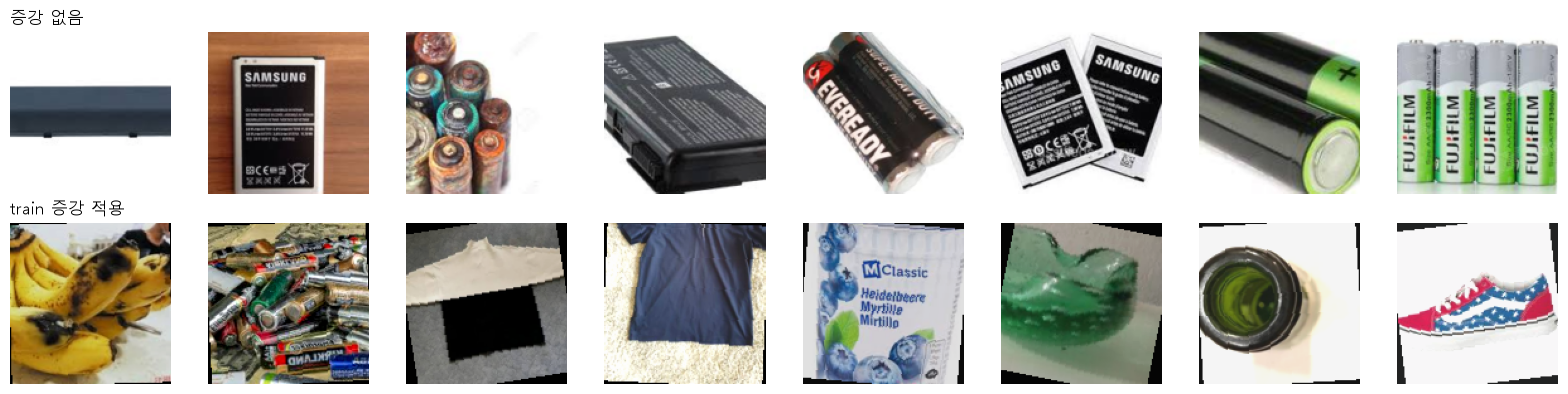

In [14]:
# 증강 적용 전후 비교: train(증강 적용) vs eval(증강 없음) 배치 시각화
def denorm(img_t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (img_t * std + mean).clamp(0, 1)

xb, yb = next(iter(train_loader))
xb_eval, _ = next(iter(DataLoader(ManifestDataset([paths[i] for i in train_idx[:8]],
                                                  targets[train_idx[:8]], transform=eval_tf),
                                  batch_size=8)))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(denorm(xb_eval[i]).permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[1, i].imshow(denorm(xb[i]).permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
axes[0, 0].set_title('증강 없음', loc='left')
axes[1, 0].set_title('train 증강 적용', loc='left')
plt.tight_layout()
plt.show()


## 5. 모델링 — 베이스라인 CNN vs 전이학습(EfficientNetV2-S, freeze/unfreeze)

In [15]:
# 베이스라인: 처음부터 학습하는 얕은 CNN
def conv_block(in_ch, out_ch):
    return [
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)]

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()
        self.features = nn.Sequential(
            *conv_block(3, 32), nn.MaxPool2d(2),
            *conv_block(32, 64), nn.MaxPool2d(2),
            *conv_block(64, 128), nn.MaxPool2d(2),
            *conv_block(128, 256), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

summarize(BaselineCNN(num_classes=len(class_names)), 'BaselineCNN')


BaselineCNN - 전체 파라미터: 392,460 / 학습 파라미터: 392,460


In [16]:
EPOCHS_BASE = 30  # 조기 종료가 있으므로 상한을 넉넉히 잡는다

baseline_model = BaselineCNN(num_classes=len(class_names))
baseline_history = train_model(baseline_model, train_loader, val_loader,
                               epochs=EPOCHS_BASE, lr=1e-3, patience=5,
                               class_weights=class_weights if use_class_weight_final else None,
                               ckpt_path='best_baseline_cnn_v3.pt', label='BaselineCNN')


[BaselineCNN] Epoch 1/30:   0%|          | 0/170 [00:00<?, ?it/s]

[BaselineCNN] Epoch 1/30 (27.4s) train_loss=1.6667 train_acc=0.4470 val_loss=1.5222 val_acc=0.5013 val_macro_f1=0.4647 val_macro_recall=0.5318


[BaselineCNN] Epoch 2/30:   0%|          | 0/170 [00:00<?, ?it/s]

[BaselineCNN] Epoch 2/30 (28.5s) train_loss=1.4550 train_acc=0.5197 val_loss=1.4420 val_acc=0.5151 val_macro_f1=0.4904 val_macro_recall=0.5530


[BaselineCNN] Epoch 3/30:   0%|          | 0/170 [00:00<?, ?it/s]

...

[BaselineCNN] Epoch 13/30 (27.5s) train_loss=1.0201 train_acc=0.6583 val_loss=1.0743 val_acc=0.6398 val_macro_f1=0.6066 val_macro_recall=0.6590


[BaselineCNN] Epoch 14/30:   0%|          | 0/170 [00:00<?, ?it/s]

[BaselineCNN] Epoch 14/30 (27.4s) train_loss=1.0085 train_acc=0.6619 val_loss=1.1787 val_acc=0.6079 val_macro_f1=0.6019 val_macro_recall=0.6451


[BaselineCNN] Epoch 15/30:   0%|          | 0/170 [00:00<?, ?it/s]

[BaselineCNN] Epoch 15/30 (27.4s) train_loss=0.9769 train_acc=0.6704 val_loss=1.1529 val_acc=0.6130 val_macro_f1=0.5920 val_macro_recall=0.6552
[BaselineCNN] val_macro_f1이 5 epoch 동안 개선되지 않아 15/30 epoch에서 조기 종료


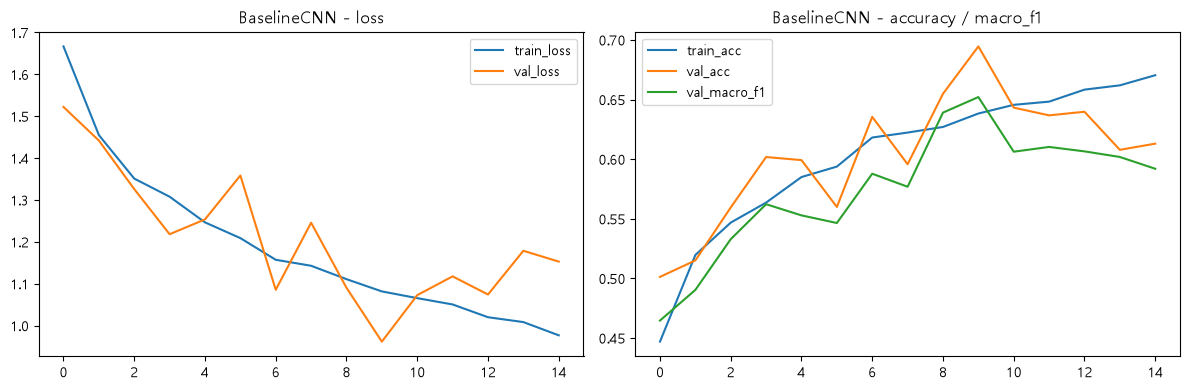

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(baseline_history['loss'], label='train_loss')
plt.plot(baseline_history['val_loss'], label='val_loss')
plt.title('BaselineCNN - loss'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(baseline_history['accuracy'], label='train_acc')
plt.plot(baseline_history['val_accuracy'], label='val_acc')
plt.plot(baseline_history['val_macro_f1'], label='val_macro_f1')
plt.title('BaselineCNN - accuracy / macro_f1'); plt.legend()
plt.tight_layout()
plt.show()


In [18]:
EPOCHS_TRANSFER = 20  # 조기 종료가 있으므로 상한을 넉넉히 잡는다

transfer_model = TransferModel(num_classes=len(class_names), freeze=True)
transfer_history = train_model(transfer_model, train_loader, val_loader,
                               epochs=EPOCHS_TRANSFER, lr=5e-4, patience=4,
                               class_weights=class_weights if use_class_weight_final else None,
                               ckpt_path='best_transfer_model_v3.pt', label='EfficientNetV2S(freeze)')


[EfficientNetV2S(freeze)] Epoch 1/20:   0%|          | 0/170 [00:00<?, ?it/s]

[EfficientNetV2S(freeze)] Epoch 1/20 (30.3s) train_loss=1.6317 train_acc=0.5754 val_loss=0.9908 val_acc=0.7955 val_macro_f1=0.7121 val_macro_recall=0.7250


[EfficientNetV2S(freeze)] Epoch 2/20:   0%|          | 0/170 [00:00<?, ?it/s]

[EfficientNetV2S(freeze)] Epoch 2/20 (30.9s) train_loss=1.0544 train_acc=0.7051 val_loss=0.7663 val_acc=0.8154 val_macro_f1=0.7398 val_macro_recall=0.7482


[EfficientNetV2S(freeze)] Epoch 3/20:   0%|          | 0/170 [00:00<?, ?it/s]

...

[EfficientNetV2S(freeze)] Epoch 12/20 (31.9s) train_loss=0.7124 train_acc=0.7791 val_loss=0.5110 val_acc=0.8563 val_macro_f1=0.7972 val_macro_recall=0.8088


[EfficientNetV2S(freeze)] Epoch 13/20:   0%|          | 0/170 [00:00<?, ?it/s]

[EfficientNetV2S(freeze)] Epoch 13/20 (31.3s) train_loss=0.7221 train_acc=0.7745 val_loss=0.4999 val_acc=0.8598 val_macro_f1=0.8001 val_macro_recall=0.8073


[EfficientNetV2S(freeze)] Epoch 14/20:   0%|          | 0/170 [00:00<?, ?it/s]

[EfficientNetV2S(freeze)] Epoch 14/20 (31.1s) train_loss=0.6976 train_acc=0.7848 val_loss=0.4920 val_acc=0.8628 val_macro_f1=0.8053 val_macro_recall=0.8113
[EfficientNetV2S(freeze)] val_macro_f1이 4 epoch 동안 개선되지 않아 14/20 epoch에서 조기 종료


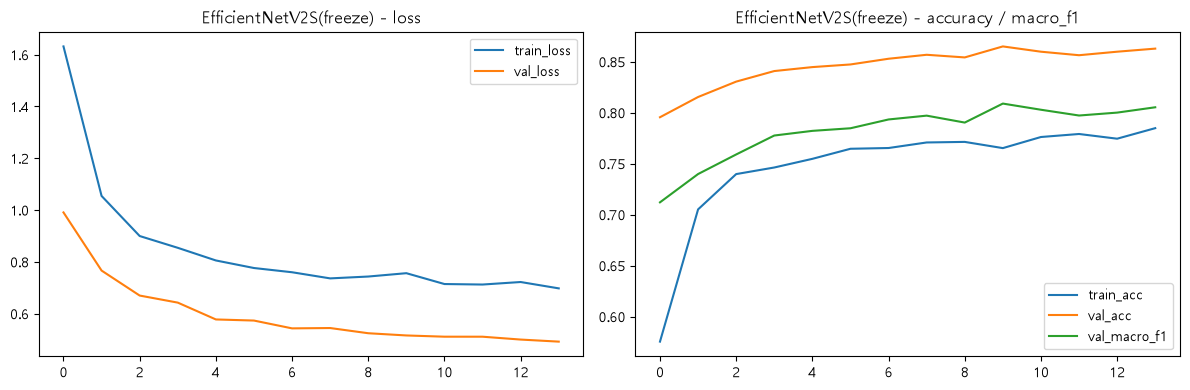

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(transfer_history['loss'], label='train_loss')
plt.plot(transfer_history['val_loss'], label='val_loss')
plt.title('EfficientNetV2S(freeze) - loss'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(transfer_history['accuracy'], label='train_acc')
plt.plot(transfer_history['val_accuracy'], label='val_acc')
plt.plot(transfer_history['val_macro_f1'], label='val_macro_f1')
plt.title('EfficientNetV2S(freeze) - accuracy / macro_f1'); plt.legend()
plt.tight_layout()
plt.show()


### 5-1. 전이학습(unfreeze) 학습률 비교 — 정제 데이터로 재탐색 (val 기준)

**시행착오**: 처음엔 `1.ipynb`처럼 스케줄러 없이 짧게(4epoch) 스윕해서 lr 하나를 고르고 그 값으로만 최종(15epoch+스케줄러+조기종료) 학습을 했다. 그 결과 4epoch 스윕에서는 `1e-4`(val_macro_f1 0.9629)가 `5e-5`(0.9538)를 앞섰지만, 그 lr로 실제 최종 학습을 돌리자 조기 종료(patience=3)가 스케줄러가 개입하기도 전인 6epoch째 발동해 최종 val_macro_f1이 0.9652에 그쳤다 — `1.ipynb`에서 `5e-5`로 15epoch 다 채워 스케줄러 혜택까지 받은 결과(0.9680)보다 오히려 낮았다. 즉 **짧은 스윕 순위가 실제 최종 학습(조기종료+스케줄러 포함) 결과를 보장하지 않는다는 게 재현됐다.**

그래서 이번엔 미니 스윕을 아예 없애고, **lr 후보 3개를 전부 최종 설정 그대로(scheduler + 조기종료, 최대 15epoch) 끝까지 학습**한 뒤, 다음 절에서 베이스라인·freeze와 함께 검증 macro F1으로 직접 비교해서 고른다.

In [20]:
UNFREEZE_LR_CANDIDATES = [5e-5, 1e-4, 3e-4]
EPOCHS_TRANSFER_UNFREEZE = 15  # 조기 종료가 있으므로 상한을 넉넉히 잡는다

# 학습률 스케줄러(ReduceLROnPlateau): val_loss가 1epoch 동안 개선 안 되면 lr을 0.1배로 낮춘다
unfreeze_histories = {}
for lr in UNFREEZE_LR_CANDIDATES:
    model = TransferModel(num_classes=len(class_names), freeze=False)
    history = train_model(model, train_loader, val_loader,
                          epochs=EPOCHS_TRANSFER_UNFREEZE, lr=lr, patience=3,
                          use_scheduler=True, scheduler_patience=1,
                          class_weights=class_weights if use_class_weight_final else None,
                          ckpt_path=f'unfreeze_lr_{lr:.0e}_v3.pt', label=f'unfreeze lr={lr:.0e}')
    unfreeze_histories[lr] = history


[unfreeze lr=5e-05] Epoch 1/15:   0%|          | 0/170 [00:00<?, ?it/s]

[unfreeze lr=5e-05] Epoch 1/15 (53.7s) train_loss=1.3752 train_acc=0.6268 val_loss=0.3192 val_acc=0.9254 val_macro_f1=0.8988 val_macro_recall=0.9003 lr=5.0e-05


[unfreeze lr=5e-05] Epoch 2/15:   0%|          | 0/170 [00:00<?, ?it/s]

[unfreeze lr=5e-05] Epoch 2/15 (53.3s) train_loss=0.3217 train_acc=0.9090 val_loss=0.1539 val_acc=0.9573 val_macro_f1=0.9419 val_macro_recall=0.9396 lr=5.0e-05


[unfreeze lr=5e-05] Epoch 3/15:   0%|          | 0/170 [00:00<?, ?it/s]

...

[unfreeze lr=3e-04] Epoch 11/15 (53.9s) train_loss=0.0196 train_acc=0.9943 val_loss=0.0871 val_acc=0.9754 val_macro_f1=0.9634 val_macro_recall=0.9617 lr=3.0e-05


[unfreeze lr=3e-04] Epoch 12/15:   0%|          | 0/170 [00:00<?, ?it/s]

[unfreeze lr=3e-04] Epoch 12/15 (54.0s) train_loss=0.0181 train_acc=0.9939 val_loss=0.0874 val_acc=0.9750 val_macro_f1=0.9623 val_macro_recall=0.9611 lr=3.0e-05


[unfreeze lr=3e-04] Epoch 13/15:   0%|          | 0/170 [00:00<?, ?it/s]

[unfreeze lr=3e-04] Epoch 13/15 (53.3s) train_loss=0.0145 train_acc=0.9947 val_loss=0.0885 val_acc=0.9750 val_macro_f1=0.9639 val_macro_recall=0.9636 lr=3.0e-06
[unfreeze lr=3e-04] val_macro_f1이 3 epoch 동안 개선되지 않아 13/15 epoch에서 조기 종료


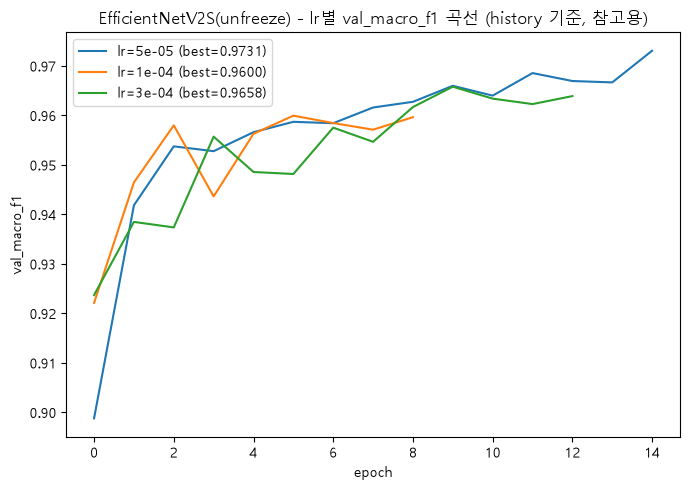

In [21]:
plt.figure(figsize=(7, 5))
for lr, history in unfreeze_histories.items():
    plt.plot(history['val_macro_f1'], label=f'lr={lr:.0e} (best={max(history["val_macro_f1"]):.4f})')
plt.xlabel('epoch'); plt.ylabel('val_macro_f1')
plt.title('EfficientNetV2S(unfreeze) - lr별 val_macro_f1 곡선 (history 기준, 참고용)')
plt.legend()
plt.tight_layout()
plt.show()


## 6. 검증 성능 비교 및 최종 모델 선정

조기 종료를 쓰면 마지막 epoch이 최고 성능이 아닐 수 있으므로, `history`의 마지막 값이 아니라 저장된 best 체크포인트를 다시 불러와 `val_loader`로 평가한다. 베이스라인·freeze·unfreeze(lr 3종) 총 5개 후보를 전부 이 방식으로 비교해 최종 모델을 고른다 — 모델 구조와 하이퍼파라미터(lr)를 같은 기준(검증 macro F1)으로 한 번에 비교하는 것.

In [22]:
candidate_specs = [
    ("BaselineCNN", "best_baseline_cnn_v3.pt",
     lambda: BaselineCNN(num_classes=len(class_names))),
    ("EfficientNetV2S(freeze)", "best_transfer_model_v3.pt",
     lambda: TransferModel(num_classes=len(class_names), freeze=True)),
] + [
    (f"EfficientNetV2S(unfreeze lr={lr:.0e})", f"unfreeze_lr_{lr:.0e}_v3.pt",
     lambda: TransferModel(num_classes=len(class_names), freeze=False))
    for lr in UNFREEZE_LR_CANDIDATES
]

criterion = nn.CrossEntropyLoss(weight=class_weights if use_class_weight_final else None)

print(f'{"모델":32s}{"val_loss":>10s}{"val_acc":>10s}{"val_macro_f1":>14s}{"val_macro_recall":>18s}')
candidates = []
for name, ckpt, builder in candidate_specs:
    model = builder()
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model = model.to(device)
    m = evaluate(model, val_loader, criterion)
    print(f'{name:32s}{m["loss"]:10.4f}{m["accuracy"]:10.4f}'
          f'{m["macro_f1"]:14.4f}{m["macro_recall"]:18.4f}')
    candidates.append((name, m, ckpt, model))

best_name, best_val_metrics, best_ckpt, best_model = max(candidates, key=lambda x: x[1]['macro_f1'])
print(f'\n검증 macro F1 기준 최종 선정 모델: {best_name}')


모델                                val_loss   val_acc  val_macro_f1  val_macro_recall


BaselineCNN                         0.9618    0.6946        0.6521            0.6639


EfficientNetV2S(freeze)             0.5158    0.8650        0.8089            0.8162


EfficientNetV2S(unfreeze lr=5e-05)    0.0869    0.9806        0.9731            0.9718


EfficientNetV2S(unfreeze lr=1e-04)    0.0940    0.9737        0.9600            0.9604


EfficientNetV2S(unfreeze lr=3e-04)    0.0895    0.9767        0.9658            0.9651

검증 macro F1 기준 최종 선정 모델: EfficientNetV2S(unfreeze lr=5e-05)


## 7. 최종 모델 평가 (test)

In [23]:
test_metrics = evaluate(best_model, test_loader)
print(f'[TEST / {best_name}] accuracy={test_metrics["accuracy"]:.4f} '
      f'macro_f1={test_metrics["macro_f1"]:.4f} macro_recall={test_metrics["macro_recall"]:.4f}')
print()
print(classification_report(test_metrics['trues'], test_metrics['preds'],
                            target_names=class_names, zero_division=0))


[TEST / EfficientNetV2S(unfreeze lr=5e-05)] accuracy=0.9773 macro_f1=0.9671 macro_recall=0.9668

              precision    recall  f1-score   support

     battery       0.99      0.97      0.98       143
  biological       0.99      0.99      0.99       149
 brown-glass       0.95      0.98      0.96        92
   cardboard       0.99      0.93      0.96       135
     clothes       0.99      1.00      1.00       793
 green-glass       0.99      0.98      0.98        93
       metal       0.90      0.97      0.93       116
       paper       0.95      0.99      0.97       158
     plastic       0.92      0.90      0.91       130
       shoes       0.99      0.99      0.99       304
       trash       0.97      0.97      0.97       105
 white-glass       0.98      0.95      0.96       116

    accuracy                           0.98      2334
   macro avg       0.97      0.97      0.97      2334
weighted avg       0.98      0.98      0.98      2334



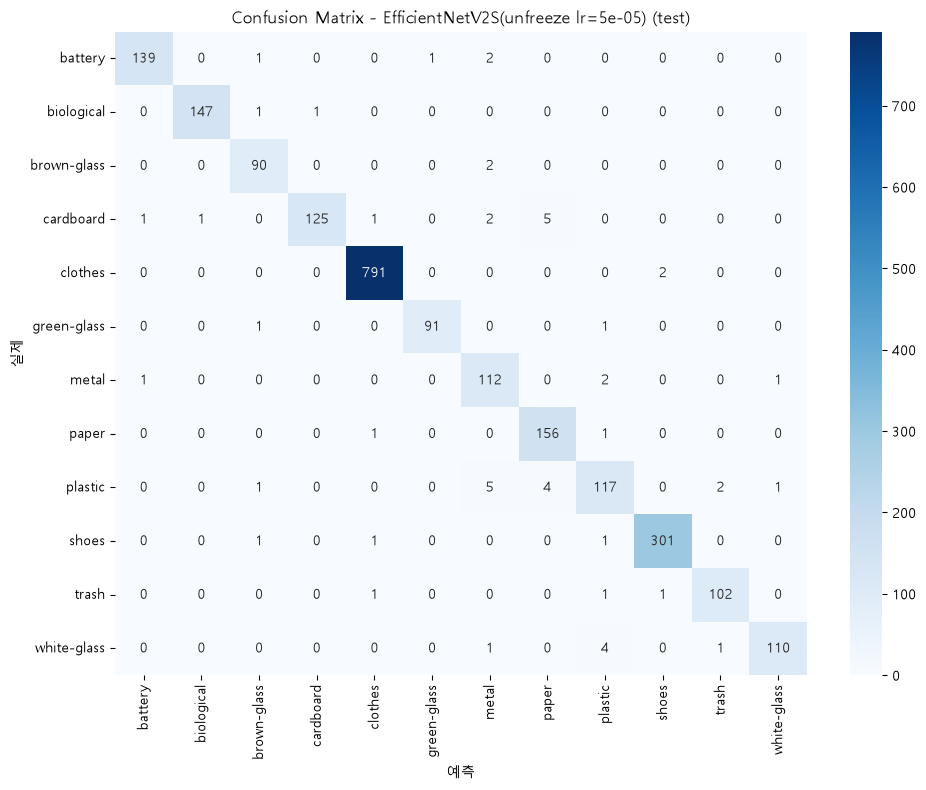

상위 오분류 쌍(실제->예측, 건수):
  cardboard -> paper: 5건
  plastic -> metal: 5건
  plastic -> paper: 4건
  white-glass -> plastic: 4건
  battery -> metal: 2건
  brown-glass -> metal: 2건
  cardboard -> metal: 2건
  clothes -> shoes: 2건
  metal -> plastic: 2건
  plastic -> trash: 2건


In [24]:
import seaborn as sns

cm = confusion_matrix(test_metrics['trues'], test_metrics['preds'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('예측'); plt.ylabel('실제')
plt.title(f'Confusion Matrix - {best_name} (test)')
plt.tight_layout()
plt.show()

# 상위 오분류 쌍
off_diag = cm.copy().astype(float)
np.fill_diagonal(off_diag, 0)
pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and off_diag[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(off_diag[i, j])))
pairs.sort(key=lambda x: -x[2])
print('상위 오분류 쌍(실제->예측, 건수):')
for a, b, n in pairs[:10]:
    print(f'  {a} -> {b}: {n}건')


## 8. 결과 해석 — Grad-CAM

최종 선정 모델(`best_model`)에서 재학습 없이 바로 근거 영역을 시각화한다.

In [25]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)

        self.model.zero_grad()
        score = logits[torch.arange(len(logits)), class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = F.relu(cam)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.cpu().numpy(), class_idx.cpu().numpy(), logits.softmax(dim=1).detach().cpu().numpy()


target_layer = best_model.features[-1] if hasattr(best_model, 'features') else None
gradcam = GradCAM(best_model, target_layer)


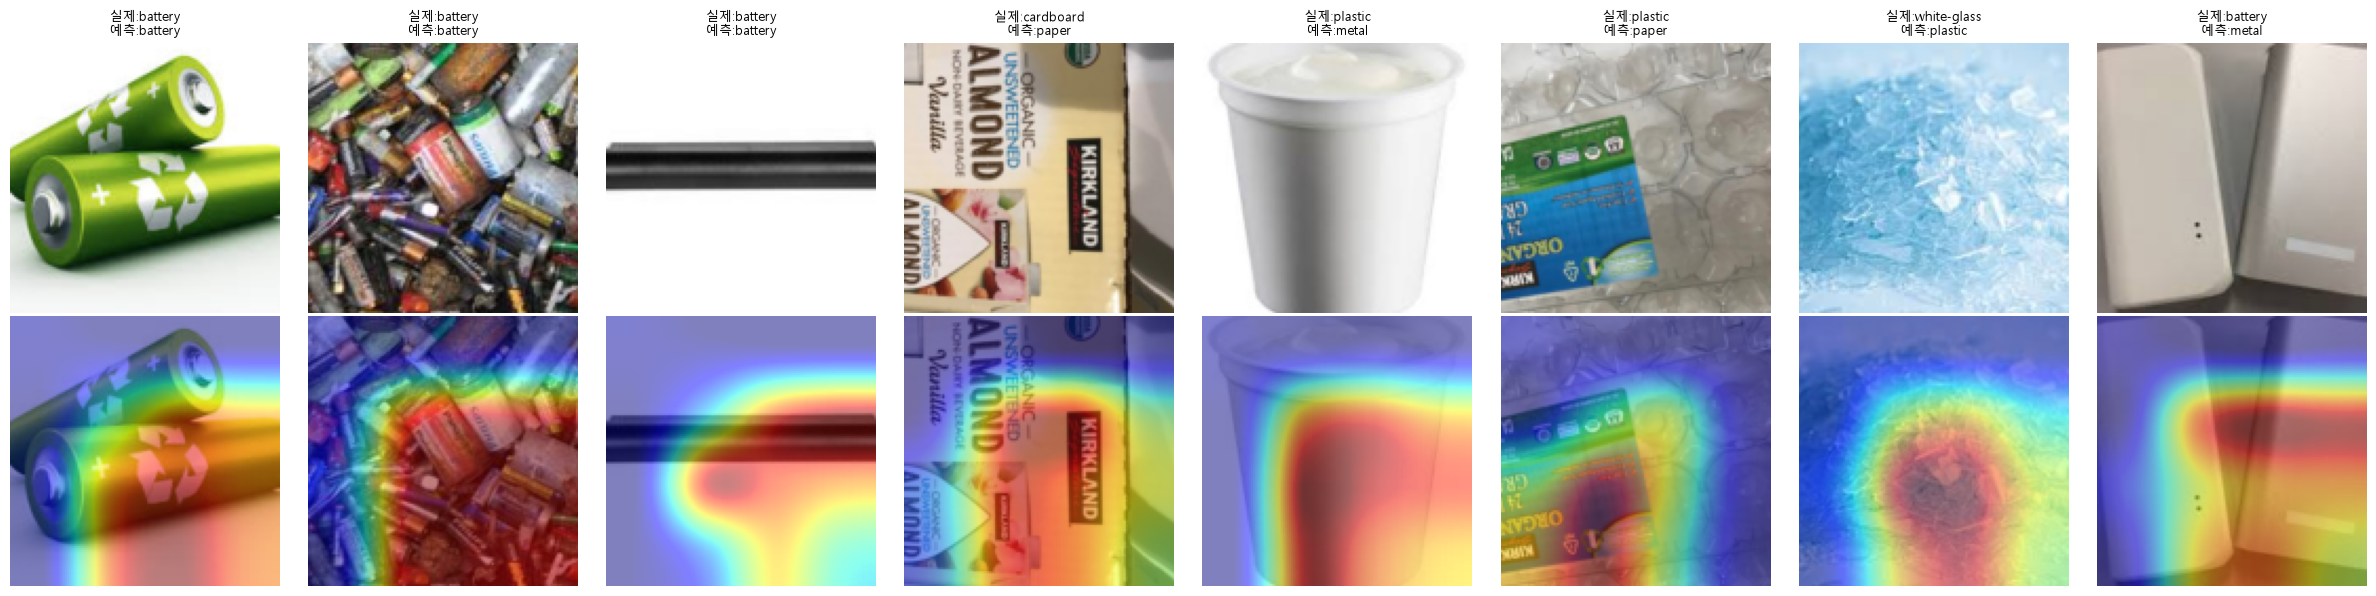

In [26]:
# 무작위 배치 대신, 잘 맞춘 예시 3장 + 위에서 확인한 상위 오분류 쌍 5장을 골라서 확인
preds, trues = test_metrics['preds'], test_metrics['trues']
correct_idx = np.where(preds == trues)[0][:3]

pair_idx = []
for a, b, _ in pairs[:5]:
    ai, bi = class_to_idx[a], class_to_idx[b]
    hit = np.where((trues == ai) & (preds == bi))[0]
    if len(hit) > 0:
        pair_idx.append(hit[0])

show_idx = list(correct_idx) + pair_idx
fig, axes = plt.subplots(2, len(show_idx), figsize=(3 * len(show_idx), 6))
for col, idx in enumerate(show_idx):
    img_t, label = test_set[idx]
    xb = img_t.unsqueeze(0).to(device)
    cam, pred_idx, probs = gradcam(xb)

    img_np = denorm(img_t).permute(1, 2, 0).numpy()
    cam_resized = np.array(Image.fromarray((cam[0] * 255).astype(np.uint8)).resize((IMAGE_SIZE, IMAGE_SIZE))) / 255.0

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'실제:{class_names[label]}\n예측:{class_names[pred_idx[0]]}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(img_np)
    axes[1, col].imshow(cam_resized, cmap='jet', alpha=0.5)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()


## 9. test 오분류 전수 확인 (확신도 기준, 이미지)

최종 test 평가에서 나온 오분류를 확신도(softmax 확률) 내림차순으로 전부 이미지로 직접 확인한다. `1.ipynb`의 5-1/5-2와 같은 목적 — 진짜 헷갈리는 사진인지, 아직 못 잡은 라벨 오류인지 판단.

In [27]:
@torch.no_grad()
def get_probs(model, loader):
    model.eval()
    probs_all = []
    for xb, yb in loader:
        xb = xb.to(device)
        probs = F.softmax(model(xb), dim=1)
        probs_all.append(probs.cpu().numpy())
    return np.concatenate(probs_all)

test_probs = get_probs(best_model, test_loader)
test_preds_all = test_probs.argmax(axis=1)
test_conf = test_probs.max(axis=1)
test_trues_all = np.array(test_set.targets)

wrong_mask = test_preds_all != test_trues_all
wrong_pos = np.where(wrong_mask)[0]
order = wrong_pos[np.argsort(-test_conf[wrong_pos])]

print(f'test {len(test_set)}장 중 오분류 {wrong_mask.sum()}건, 확신도 내림차순 전수 확인')
print(f'\n{"#":>3s} {"실제":12s} {"예측":12s} {"확신도":>6s}  파일명')
for rank, pos in enumerate(order, 1):
    fname = os.path.basename(test_set.paths[pos])
    print(f'{rank:3d} {class_names[test_trues_all[pos]]:12s} {class_names[test_preds_all[pos]]:12s} '
          f'{test_conf[pos]:6.3f}  {fname}')


test 2334장 중 오분류 53건, 확신도 내림차순 전수 확인

  # 실제           예측              확신도  파일명
  1 brown-glass  metal         0.999  brown-glass247.jpg
  2 plastic      metal         0.998  plastic16.jpg
  3 paper        plastic       0.997  paper8.jpg
  4 cardboard    paper         0.996  cardboard442.jpg
  5 trash        clothes       0.992  trash548.jpg
  6 cardboard    paper         0.984  cardboard178.jpg
  7 clothes      shoes         0.982  clothes913.jpg
  8 plastic      trash         0.979  plastic540.jpg
  9 trash        shoes         0.975  trash640.jpg
 10 metal        battery       0.969  metal676.jpg
 11 battery      brown-glass   0.954  battery872.jpg
 12 shoes        clothes       0.950  shoes275.jpg
 13 green-glass  brown-glass   0.950  white-glass704.jpg
 14 white-glass  plastic       0.949  white-glass430.jpg
 15 plastic      brown-glass   0.941  plastic166.jpg
 16 cardboard    metal         0.940  cardboard540.jpg
 17 plastic      paper         0.937  plastic386.jpg
 18 paper     

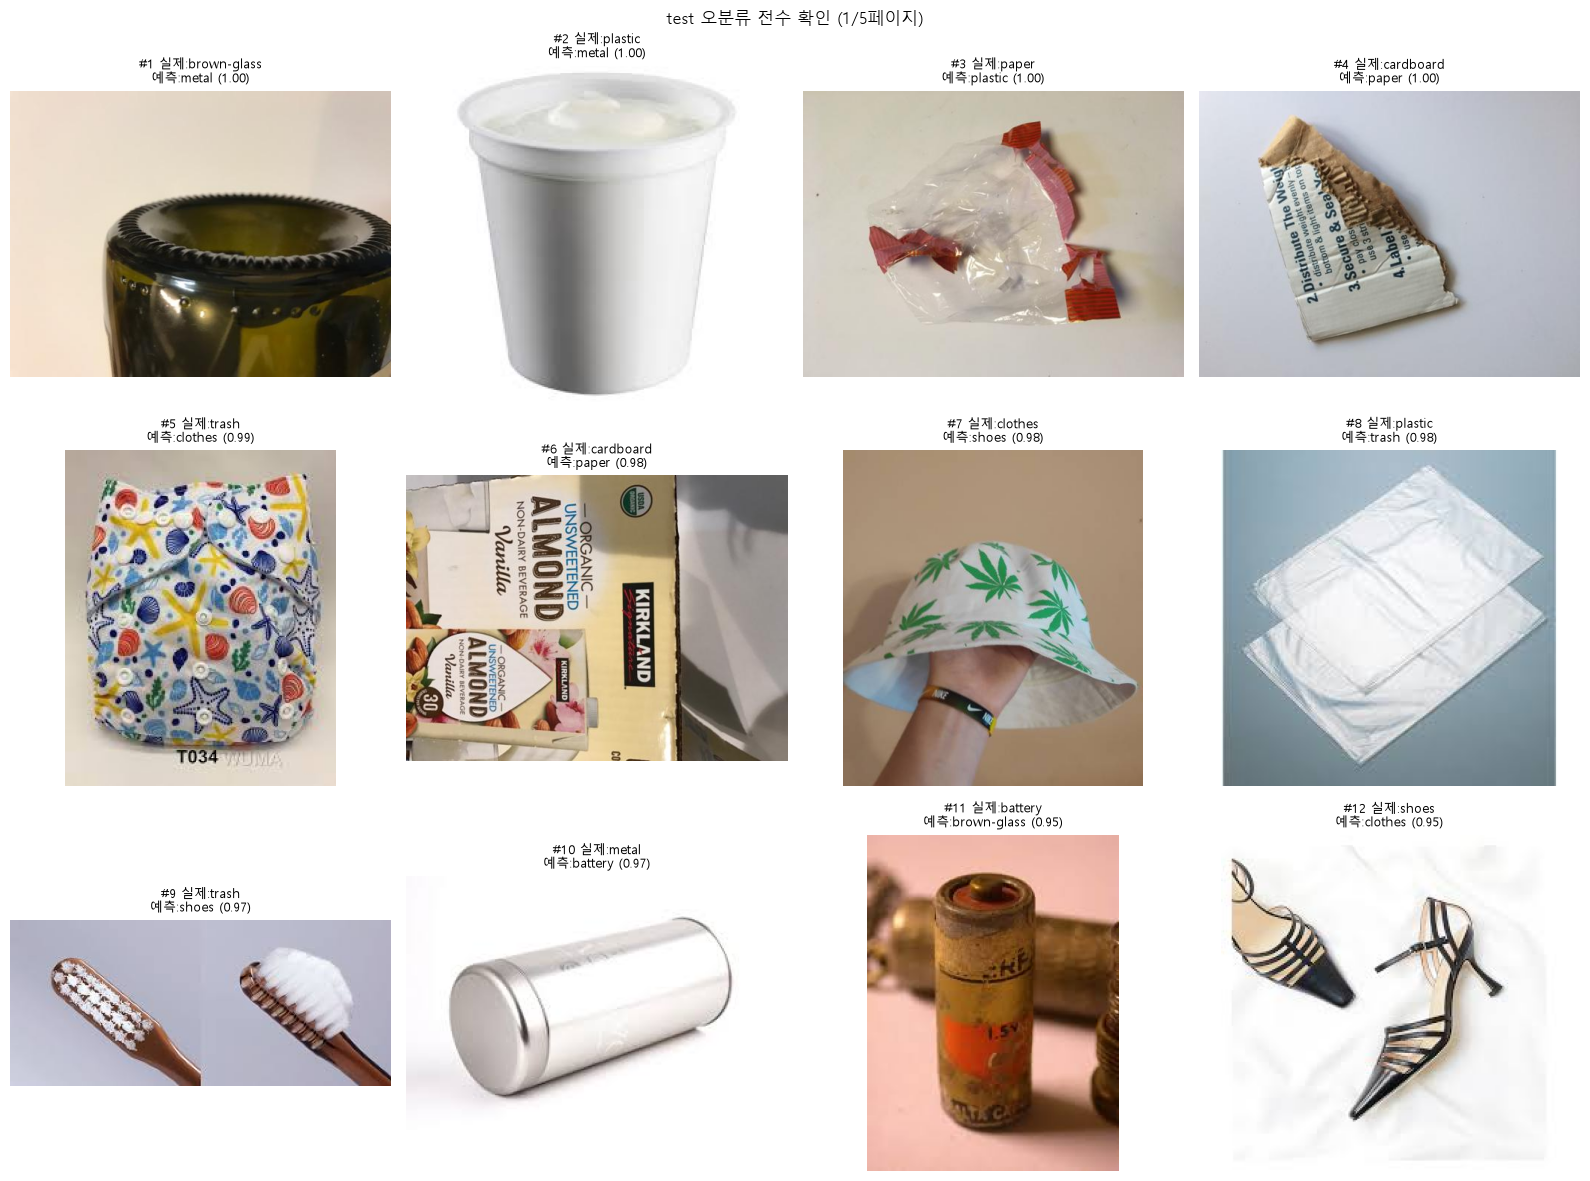

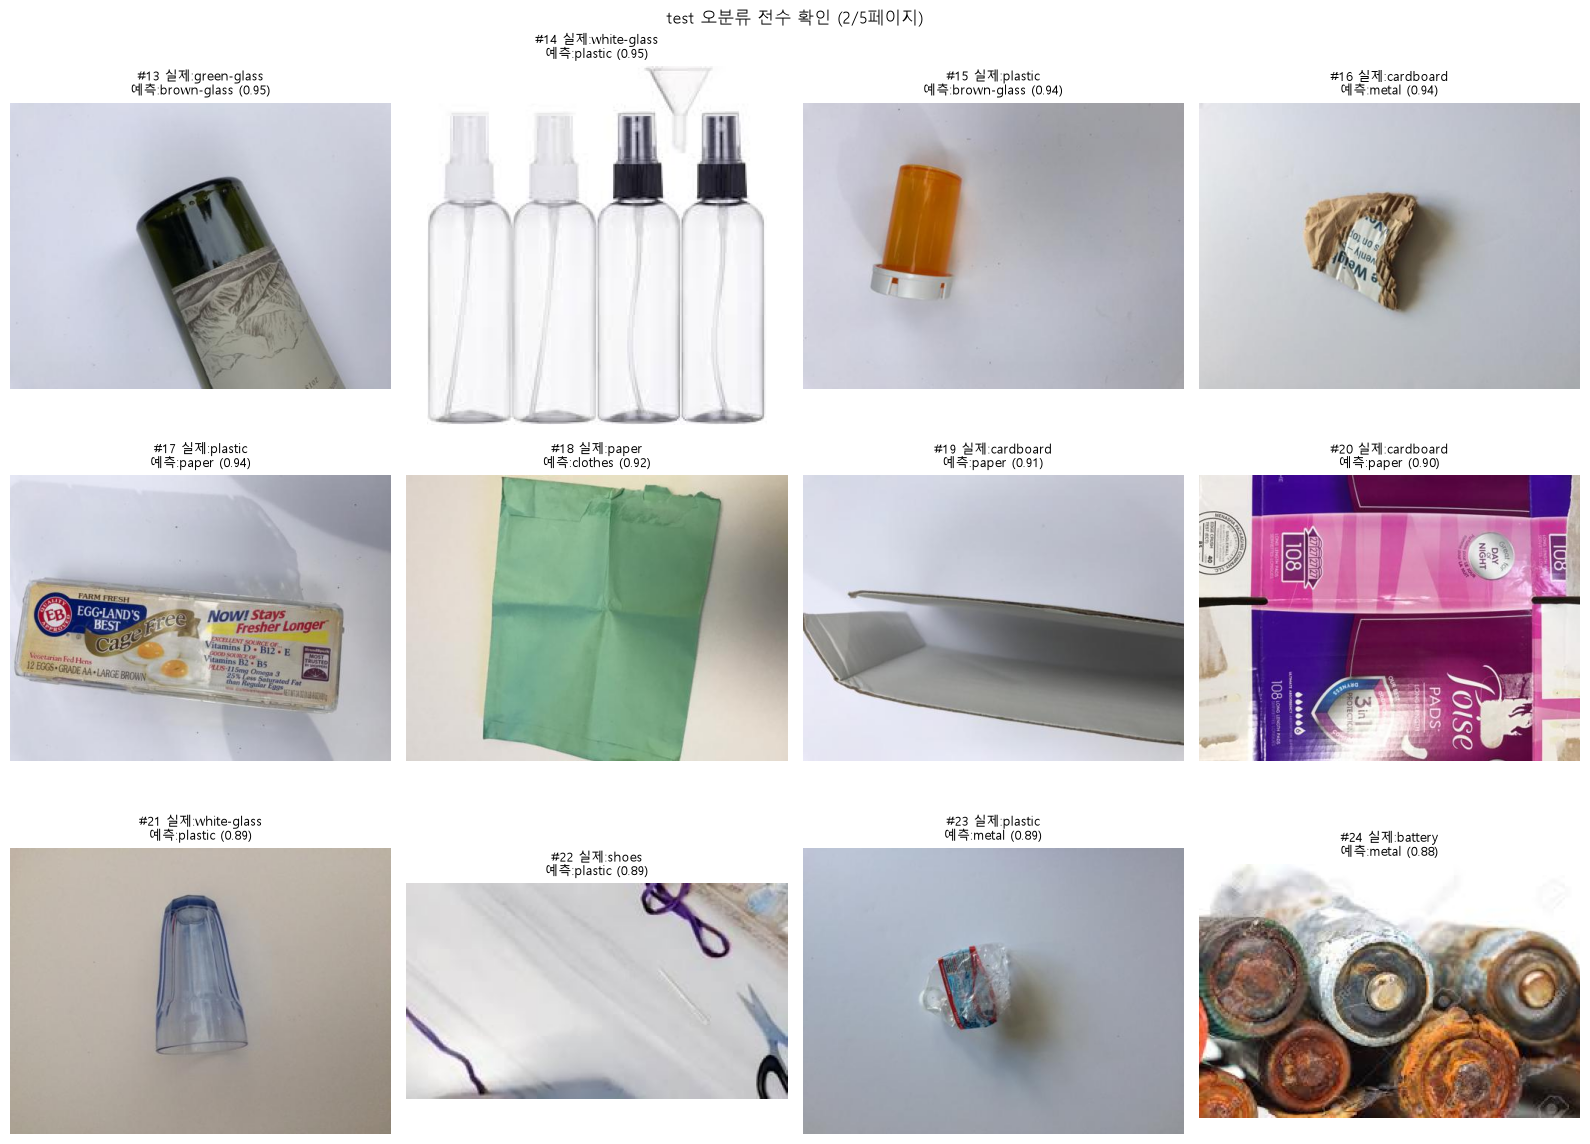

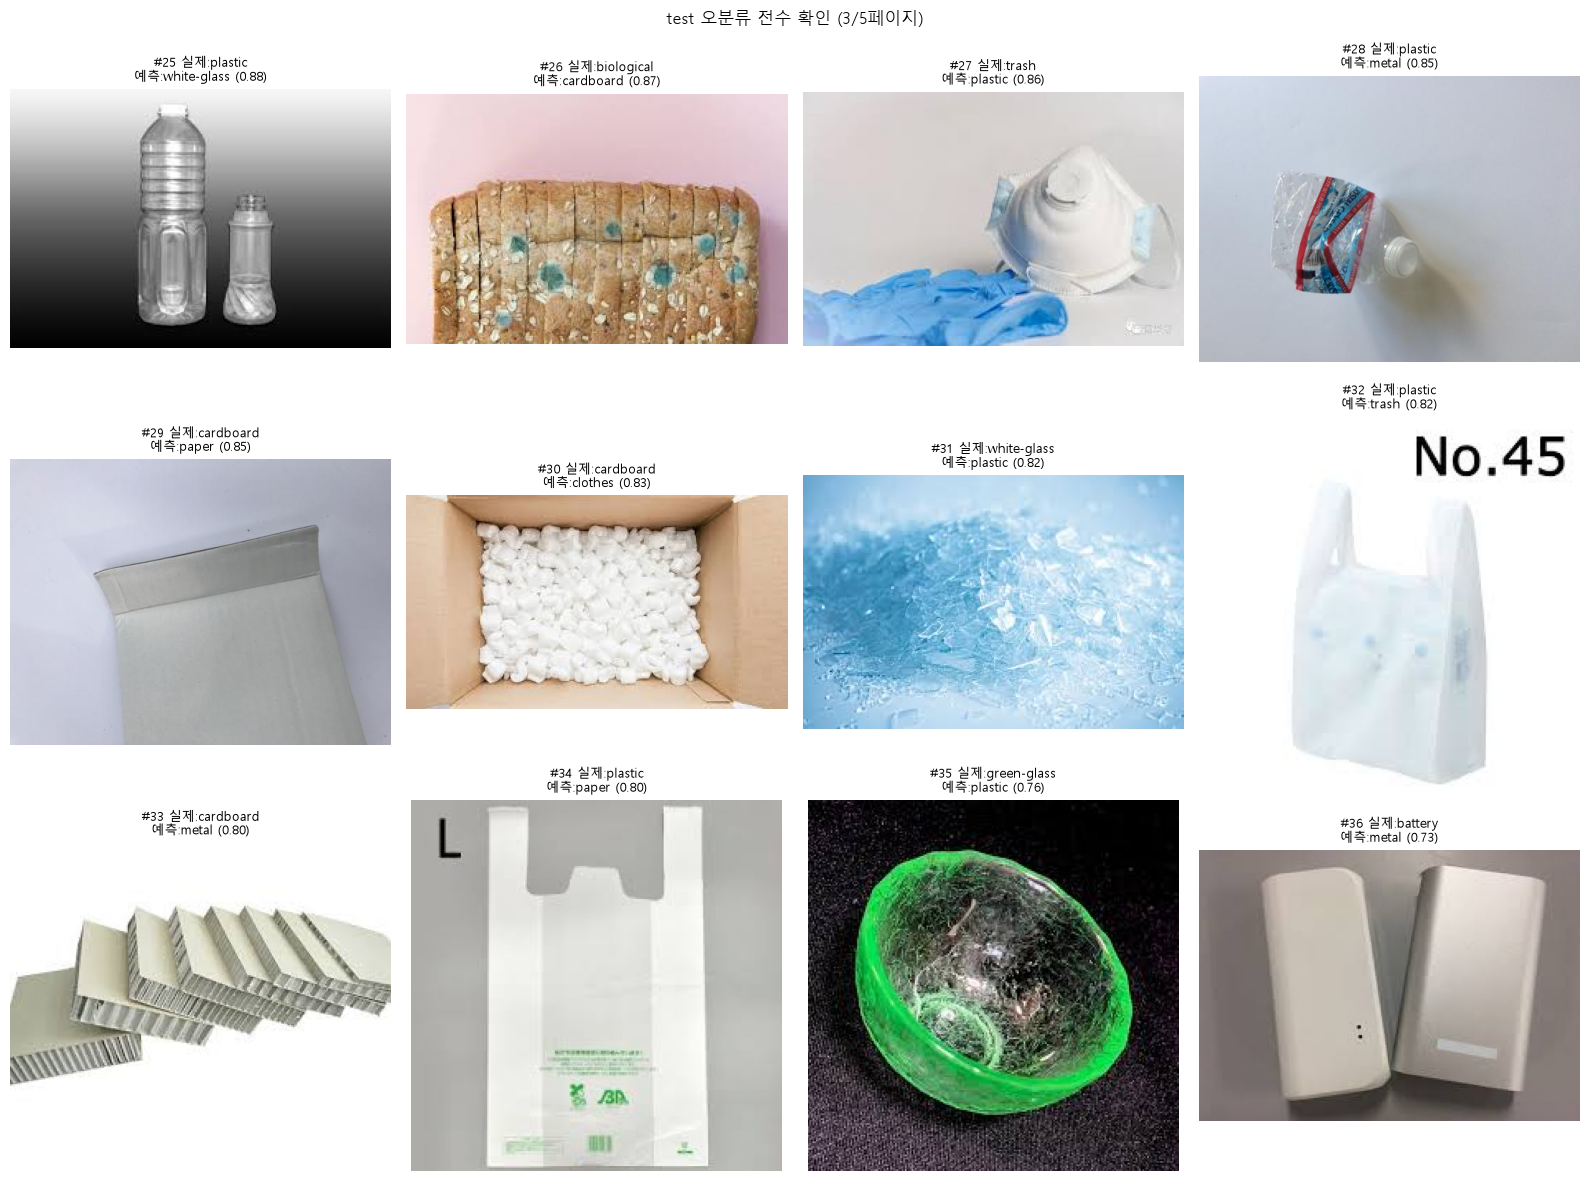

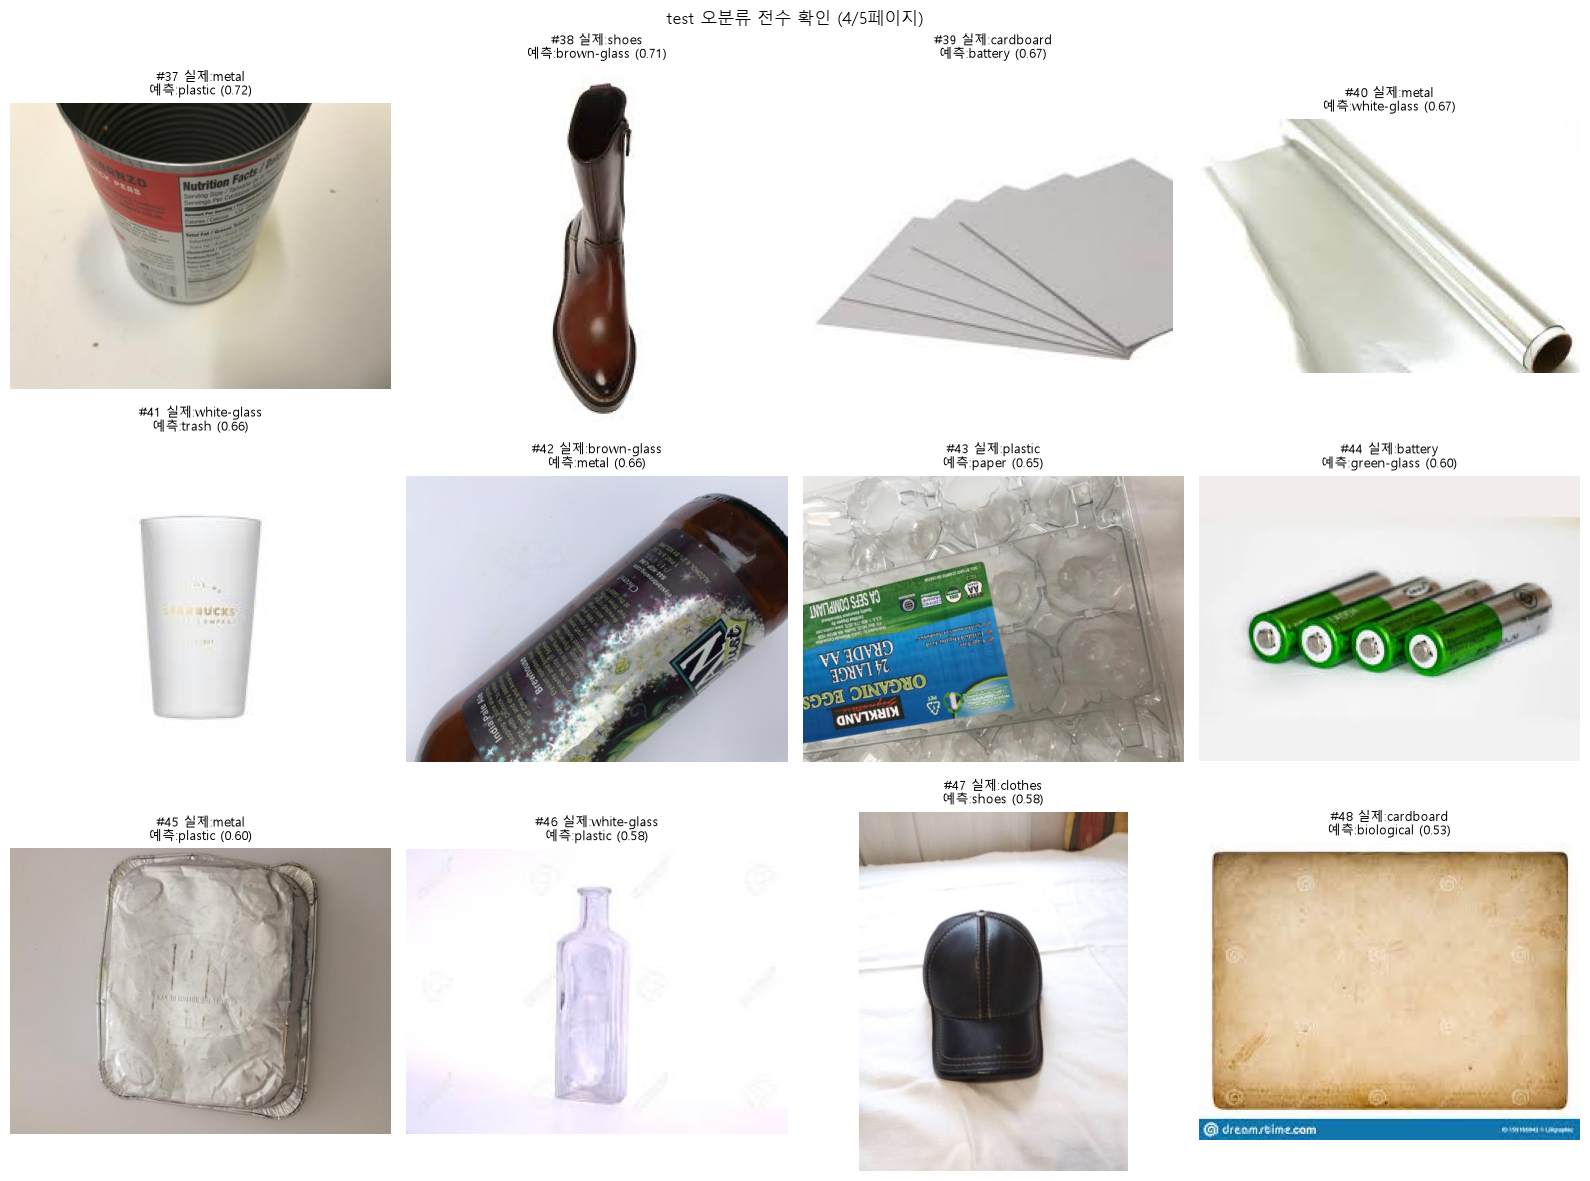

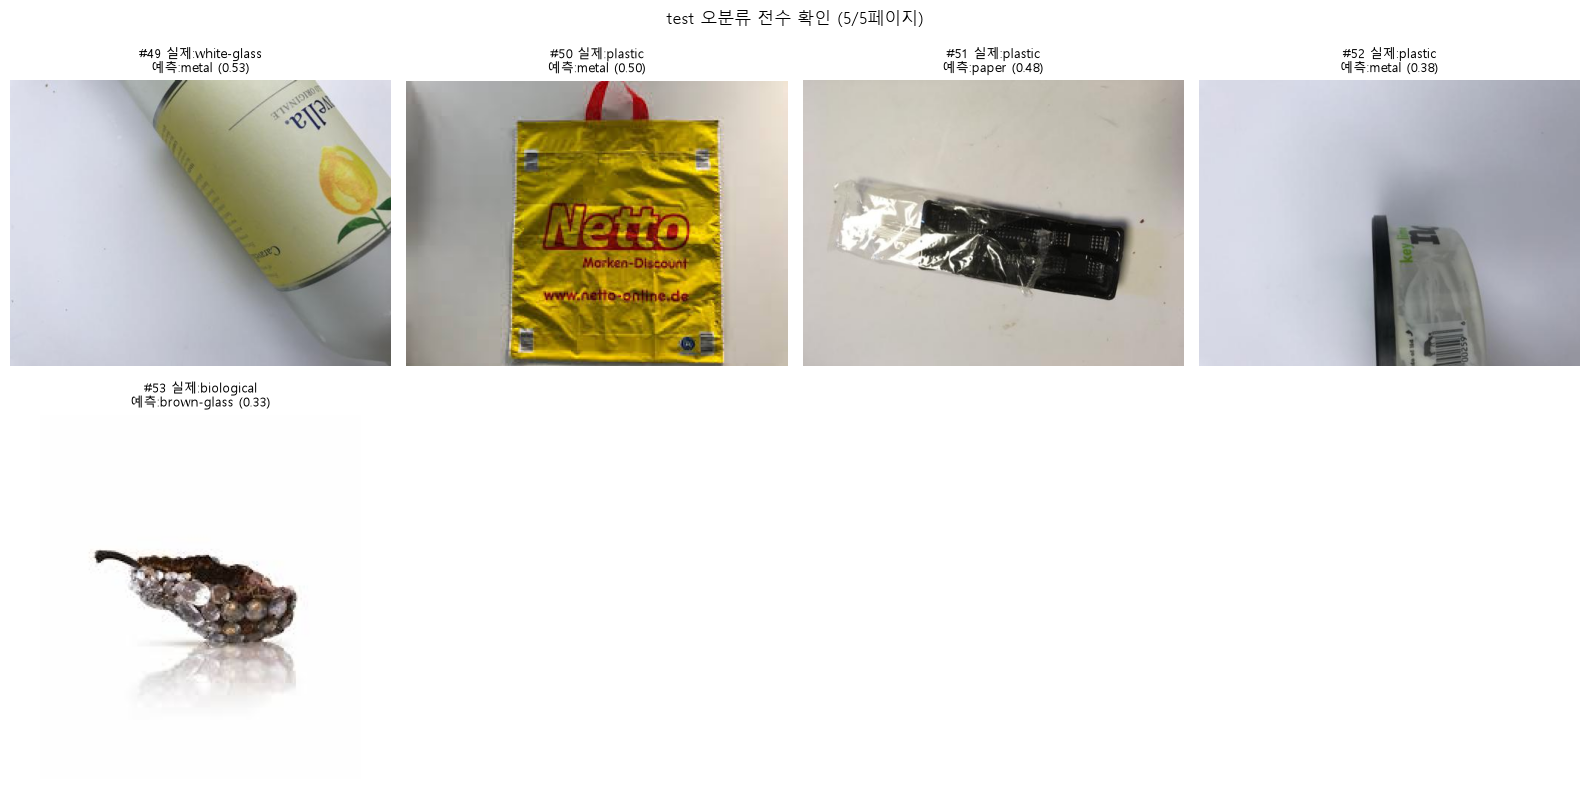

In [28]:
PER_PAGE = 12
n_pages = (len(order) + PER_PAGE - 1) // PER_PAGE
for p in range(n_pages):
    chunk = order[p * PER_PAGE:(p + 1) * PER_PAGE]
    rows = (len(chunk) + 3) // 4
    plt.figure(figsize=(16, 4 * rows))
    for k, pos in enumerate(chunk):
        path = test_set.paths[pos]
        rank = p * PER_PAGE + k + 1
        plt.subplot(rows, 4, k + 1)
        plt.imshow(Image.open(path))
        plt.title(f'#{rank} 실제:{class_names[test_trues_all[pos]]}\n'
                  f'예측:{class_names[test_preds_all[pos]]} ({test_conf[pos]:.2f})', fontsize=9)
        plt.axis('off')
    plt.suptitle(f'test 오분류 전수 확인 ({p + 1}/{n_pages}페이지)')
    plt.tight_layout()
    plt.show()


**결과 요약 (직접 확인, 확신도 0.95 이상 13건)**

확신도 0.95 이상으로 틀린 13건을 전부 열어봤다.

- **새로운 라벨오류 후보 2건**: `paper8.jpg`(실제로는 빨간 줄무늬 비닐/셀로판 포장지 — `plastic`이 맞아 보임, 모델 예측과 일치), `trash548.jpg`(실제로는 바다생물 무늬 패브릭 기저귀/천 — `clothes`에 더 가까워 보임, 모델 예측과 일치). 둘 다 기존 라벨 검토(`label_review_report.md`)에서 못 잡았던 새 사례.
- **나머지 11건은 진짜 어려운 사례**로 판단: 재질/색상이 실제로 애매하거나(`brown-glass247`이 금속성 광택이 있는 유리 절단면이라 metal로 헷갈림, `cardboard178`이 Tetra Pak 종이팩이라 paper와 경계가 모호함), 구도가 특이해서 헷갈리는 경우(`clothes913`의 모자, `shoes275`의 흰 배경 하이힐, `trash640`의 칫솔 — `2.ipynb`에서 이미 확인된 "흰 배경+세로 물체" 구도 오탐 패턴과 유사).
- `white-glass704.jpg`는 이전에 `green-glass`로 정정한 파일인데 이번엔 `brown-glass`로 또 틀림 — 애초에 색이 애매한 경계 사례였음을 재확인(팀 논의 시 `green-glass`로 정정한 게 맞는지 다시 봐도 됨).

**다음 단계 제안**: `paper8.jpg`, `trash548.jpg` 두 건을 팀에서 확인 후 맞으면 `data_cleaning_summary.md`에 추가하고 재정제할 가치가 있음(2건뿐이라 재학습해도 지표가 크게 바뀌진 않을 것으로 예상).

## 10. 결론 및 한계

- 이 노트북은 `1.ipynb`와 같은 모델링 파이프라인을 쓰되, 팀 합의로 확정한 데이터 정제 규칙을 매니페스트 방식으로 반영했다.
- **v2 변경점**: 전처리·불균형 대응 2x2 그리드와 unfreeze 학습률 스윕을 `1.ipynb`에서 이월하지 않고 정제된 데이터로 처음부터 재탐색했다 — 결론이 그대로 유지되는지, 데이터가 바뀌면서 최적 설정도 바뀌는지는 위 4절·5-1절 결과 표 참고.
- 정제 전(`1.ipynb`) 대비 test 지표 변화, 클래스별 오분류 패턴 변화는 위 결과 셀 참고. 수치 기록은 `3_notes.md`에 정리한다.
- 원본 `garbage_classification/` 폴더는 건드리지 않았으므로, 정제 규칙(위 2절의 리스트)만 이 노트북에 남아있다.
- 한계: 근접 중복/라벨 오류 탐지 자체가 완전하다는 보장은 없음(2.ipynb, label_review_report.md, label_error_detection_method.md 참고). 애매한 경계 3장과 비사진 6장은 이번엔 삭제로 처리했지만, 실제 서비스라면 재촬영/재라벨링이 더 나은 선택일 수 있음.